# Applied Data Science and Machine Learning
## A program by IITM and TalentSprint
### Assignment 04: Cross Validation

### Dataset

#### History

This is a multivariate dataset introduced by R.A.Fisher (Father of Modern Statistics) for showcasing linear discriminant analysis. This is arguably the best known dataset in Feature Selection literature.


The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other.

#### Description
The Iris dataset consists of 150 data instances. There are 3 classes (Iris Versicolor, Iris Setosa and Iris Virginica) each have 50 instances.


For each flower we have the below data attributes

- sepal length in cm
- sepal width in cm
- petal length in cm
- petal width in cm

To make our experiment easy we rename the classes  with numbers :

    "0": setosa
    "1": versicolor
    "2": virginica
    



Iris Plants are flowering plants with showy flowers. They are very popular among movie directors as it gives excellent background.

They are predominantly found in dry, semi-desert, or colder rocky mountainous areas in Europe and Asia. They have long, erect flowering stems and can produce white, yellow, orange, pink, purple, lavender, blue or brown colored flowers. There are 260 to 300 types of iris.

![alt text](https://cdn-images-1.medium.com/max/1275/1*7bnLKsChXq94QjtAiRn40w.png)

As you could see, flowers have 3 sepals and 3 petals.  The sepals are usually spreading or drop downwards and the petals stand upright, partly behind the sepal bases. However, the length and width of the sepals and petals vary for each type.


### Setup Steps:

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "" #@param {type:"string"}

In [ ]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "" #@param {type:"string"}

In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython

ipython = get_ipython()

notebook= "M2_AST_04_Cross_Validation_C" #name of the notebook
batchId = "IITM-PG-ADSML-09"

def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(),"batch": batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,"batch": batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iitm.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")



In [ ]:
#@title Run this cell to download the dataset
from IPython import get_ipython
ipython = get_ipython()

ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Iris.csv")

### Importing Required Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading the data

In [ ]:
data = pd.read_csv("Iris.csv")
data.info()

In [ ]:
data.head()

In [ ]:
# drop the coulums not required
data.drop("Id",axis = 1 , inplace = True)
data.columns

In [ ]:
data.Species.unique()

In [ ]:
# convert the catageories into numerical
data.Species=[0 if i == "Iris-setosa" else 1 if  i ==  "Iris-versicolor" else 2 for i in data.Species]
data.Species.unique()

### Get the features and labels of the dataset

In [ ]:
# Prepare data for modeling
# Separate input features and target
y = data.Species.values
X = data.drop("Species",axis = 1).values

### Splitting the data into train and test sets

Hint: [Train-Test split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)



In [ ]:
# setting up testing and training sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4)


### Training a  kNN Classifier

Hint: [kNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [ ]:
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
# Train the model
knn = KNeighborsClassifier(n_neighbors=5)
# Fit the model
knn.fit(X_train,y_train)
# Predict the test
y_pred = knn.predict(X_test)
# Accuracy of the model
print(metrics.accuracy_score(y_test, y_pred))

## **Cross-Validation (CV) of Dataset**

Cross-Validation is an important step to check the efficiency of a model and its generic behavior to new data.

The three steps involved in cross-validation are as follows :

1.   Reserve a small portion of available dataset.
2.   Use the rest of the dataset to train the model.
3.   Test the model using the reserved portion of the dataset
4.   Repeat 1-3 for different combination of Train/test data

###K-Fold Cross-Validation

**KFold Cross-Validation**

KFold Cross-Validation divides all the samples in groups of samples, called folds of approximately equal sizes (wherever possible). The prediction function is learned using  folds, and the fold left out is used for test.

Here $k$ is the number of folds. This $k$ is not to be confused with $kNN$


![](https://miro.medium.com/proxy/1*NyvaFiG_jXcGgOaouumYJQ.jpeg)

In [ ]:
from sklearn.model_selection import cross_val_score,KFold

In [ ]:
knn = KNeighborsClassifier(n_neighbors=10)
kf=KFold(n_splits=5)
# Compute the Cross Validation score using the imported function "cross_val_score"
score=cross_val_score(knn, X_train, y_train, cv=kf)




**Cross-validation Score**

We can arrange the train and test-data with 5 different combinations.
 The purpose of Cross-validation Score is to tell how much improvisation can be done with the base model (The model with default parameters)

In [ ]:
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

### Stratified K-Fold Cross-Validation

**Stratified k-fold Cross-Validation**

StratifiedKFold is a variation of k-fold which returns stratified folds: each set contains approximately the same percentage of samples of each target class as the complete set.



![](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_003.png)



In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
stratified=StratifiedKFold(n_splits=5)
# Compute the Cross Validation score using the imported function "cross_val_score"
score=cross_val_score(knn, X_train, y_train, cv=stratified)

In [ ]:
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

### Leave One Out cross-validation

**Leave One Out (LOO) Cross-validation**

LeaveOneOut (or LOO) is a simple cross-validation. Each learning set is created by taking all the samples except one, the test set being the sample left out. Thus, for  samples, we have  different training sets and  different tests set. This cross-validation procedure does not waste much data as only one sample is removed from the training set


![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c7/LOOCV.gif/1600px-LOOCV.gif)

In [ ]:
from sklearn.model_selection import LeaveOneOut

In [ ]:
loo=LeaveOneOut()
# Compute the Cross Validation score using the imported function "cross_val_score"
score=cross_val_score(knn, X_train, y_train, cv=loo)

In [ ]:
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

### Leave P Out cross-validation

**Leave P Groups Out Cross-Validation**

LeavePGroupsOut is similar as LeaveOneGroupOut, but removes samples related to $P$ groups for each training/test set

In [ ]:
from sklearn.model_selection import LeavePOut

In [ ]:
LP=LeavePOut(p=2)
# Compute the Cross Validation score using the imported function "cross_val_score"
score=cross_val_score(knn, X_train, y_train, cv=LP)

In [ ]:
print("Cross Validation Scores are \n{}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

### **Grid Search using Cross-Validation(CV)**

This is an approach which combines two steps in one step.
Here the Model parameters are varies for the specified values. For each model (combination of parameters), the model is cross-validated for different train/test datasets,



We can test the combinations of the model parameters using GridsearchCV.
More on Grid Search CV [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV).

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
k_range = list(range(1, 31))
print(k_range)

In [ ]:
# Mention all the parameters that we want to iterate across
param_grid = dict(n_neighbors=k_range)
print(param_grid)

In [ ]:
# Define and model fit the data
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(X_train, y_train)

In [ ]:
# Print the method of the grid-search cv
grid_mean_scores = grid.cv_results_['mean_test_score']
print(grid_mean_scores)

In [ ]:
plt.plot(k_range, grid_mean_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')

Let us check for the combination that yields us the best model.

In [ ]:
print(grid.best_score_)
print(grid.best_params_)
print(grid.best_estimator_)

## Bootstrap sampling method



*   Configure bootstrap
*   Run bootstrap in train, test data and obtain accuracy scores
*   Visual representation using Histogram and derive Confidence levelsList item

Here, samples from the original data are generated using a random function. There may be duplicates or more in a sample set, but it is unusual that two sample sets will be exactly the same. A bootstrapped data collection may contain numerous occurrences of the same original cases and may completely miss other original cases due to the drawing with replacement.

When making predictions on data that is not part of the training set, machine learning models can utilize this technique to measure their predictive ability. This method aids in fine-tuning the model even before test data (data from the real world) is made available to it. As a result, we can adjust the model hyperparameters to get the optimum result.

For a wide variety of statistics, bootstrapping is generally used to create empirical distribution functions.

The ability to show the estimated skill with confidence intervals, which is a characteristic not readily available with other approaches like Cross Validation, is a desirable aspect of the findings from estimating machine learning model skills.


**Confidence interval**

In statistics and machine learning, confidence intervals (CI) represent the likelihood that a population's statistical property will fall inside an estimated range. Standard deviations from the mean are used to estimate CIs. Let's assume that our data comes from a normal distribution and examine the following example to gain a better understanding:
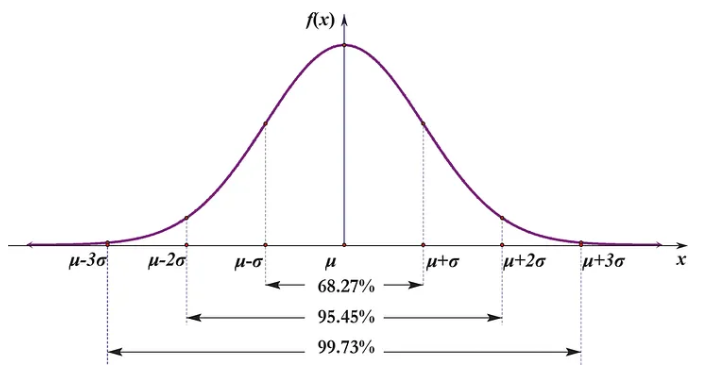

The above graphic of a normal distribution shows how, according to the three-sigma rule, 68% of data are within one standard deviation of the mean, 95% are within two standard deviations, and 99% are within three standard deviations. We may also state that the range (mean-2*std,mean+2*std) will contain 95% of the data in this study. The 95% confidence interval in this case is (mean-2*std,mean+2*std). Similar to how we can find similar confidence intervals for any other distributions, we'll demonstrate how in the implementation.

In [ ]:
from sklearn.utils import resample

In [ ]:
data.info # Iiris data
values = data.values

In [ ]:
#Lets configure Bootstrap

n_iterations = 10  #No. of bootstrap samples to be repeated (created)
n_size = int(len(data) * 0.50) #Size of sample, picking only 50% of the given data in every bootstrap sample

In [ ]:
#Lets run Bootstrap
stats = list()
for i in range(n_iterations):

    #prepare train & test sets
    train = resample(values, n_samples = n_size) #Sampling with replacement..whichever is not used in training data will be used in test data
    test = np.array([x for x in values if x.tolist() not in train.tolist()]) #picking rest of the data not considered in training sample

    #fit model
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(train[:,:-1], train[:,-1]) #model.fit(X_train,y_train) i.e model.fit(train set, train label as it is a classifier)

    #evaluate model
    predictions = model.predict(test[:,:-1]) #model.predict(X_test)
    score = metrics.accuracy_score(test[:,-1], predictions) #accuracy_score(y_test, y_pred)
    #caution, overall accuracy score can mislead when classes are imbalanced

    print(score)
    stats.append(score)

Here each Bootstrap iteration sample would create one model and this model is tested against the Out of Bag (test data) of that sample, i.e we will test that sample with the test sample not part of that sample.

In [ ]:
#Lets plot the scores to better understand this visually
plt.hist(stats)
plt.figure(figsize = (10,5))

### Confidence Intervals
Confidence intervals refers to the % of all possible samples that can be expected to include the true population parameter.

For eg. 95% of all samples would be found in this interval range.

In [ ]:
#Lets find Confidence intervals

a = 0.95 # for 95% confidence
p = ((1.0 - a)/2.0) * 100 #tail regions on right and left .25 on each side indicated by P value (border)
                          # 1.0 is total area of this curve, 2.0 is actually .025 thats the space we would want to be left on either side
lower = max(0.0, np.percentile(stats,p))

p = (a + ((1.0 - a)/ 2.0)) * 100 #p is limits
upper = min(1.0, np.percentile(stats,p))
print('%.1f confidence interval %.1f%% and %.1f%%' %(a*100, lower*100, upper*100))

## Please answer the questions below to complete the experiment:




In [ ]:
# @title State True or False: The bootstrap method is a resampling technique used to estimate statistics on a population by sampling a dataset with replacement.   { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "" #@param ["", "FALSE", "TRUE"]

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]

In [ ]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "" #@param {type:"string"}

In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "" #@param ["","Yes", "No"]

In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]

In [ ]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]

In [ ]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")